# EDA — Churn Prediction

 Exploration & Feature Engineering

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

In [2]:
df = pd.read_csv("../data/processed/customers_clean.csv")
df.shape

(7043, 21)

In [3]:
df.head()

,customerid,gender,seniorcitizen,partner,dependents,tenure,phoneservice,multiplelines,internetservice,onlinesecurity,...,deviceprotection,techsupport,streamingtv,streamingmovies,contract,paperlessbilling,paymentmethod,monthlycharges,totalcharges,churn
0,7590-VHVEG,Female,0,True,False,1,False,No phone service,DSL,No,...,No,No,No,No,Month-to-month,True,Electronic check,29.85,29.85,False
1,5575-GNVDE,Male,0,False,False,34,True,No,DSL,Yes,...,Yes,No,No,No,One year,False,Mailed check,56.95,1889.50,False
2,3668-QPYBK,Male,0,False,False,2,True,No,DSL,Yes,...,No,No,No,No,Month-to-month,True,Mailed check,53.85,108.15,True
3,7795-CFOCW,Male,0,False,False,45,False,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,False,Bank transfer (automatic),42.30,1840.75,False
4,9237-HQITU,Female,0,False,False,2,True,No,Fiber optic,No,...,No,No,No,No,Month-to-month,True,Electronic check,70.70,151.65,True


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerid        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   seniorcitizen     7043 non-null   int64  
 3   partner           7043 non-null   bool   
 4   dependents        7043 non-null   bool   
 5   tenure            7043 non-null   int64  
 6   phoneservice      7043 non-null   bool   
 7   multiplelines     7043 non-null   str    
 8   internetservice   7043 non-null   str    
 9   onlinesecurity    7043 non-null   str    
 10  onlinebackup      7043 non-null   str    
 11  deviceprotection  7043 non-null   str    
 12  techsupport       7043 non-null   str    
 13  streamingtv       7043 non-null   str    
 14  streamingmovies   7043 non-null   str    
 15  contract          7043 non-null   str    
 16  paperlessbilling  7043 non-null   bool   
 17  paymen

## 1. Distribution du churn

churn
False    73.463013
True     26.536987
Name: proportion, dtype: float64


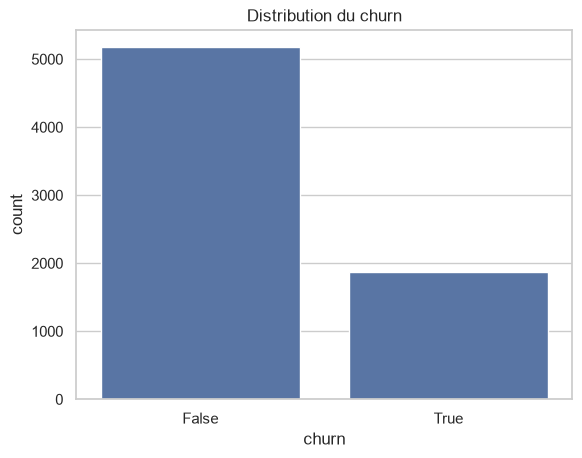

In [5]:
churn_col = "churn" if "churn" in df.columns else "Churn"
churn_rate = df[churn_col].value_counts(normalize=True) * 100
print(churn_rate)

sns.countplot(data=df, x=churn_col)
plt.title("Distribution du churn")
plt.show()

## 2. Valeurs manquantes

In [6]:
df.isnull().sum().sort_values(ascending=False)

customerid          0
gender              0
seniorcitizen       0
partner             0
dependents          0
tenure              0
phoneservice        0
multiplelines       0
internetservice     0
onlinesecurity      0
onlinebackup        0
deviceprotection    0
techsupport         0
streamingtv         0
streamingmovies     0
contract            0
paperlessbilling    0
paymentmethod       0
monthlycharges      0
totalcharges        0
churn               0
dtype: int64

## 3. Churn par type de contrat

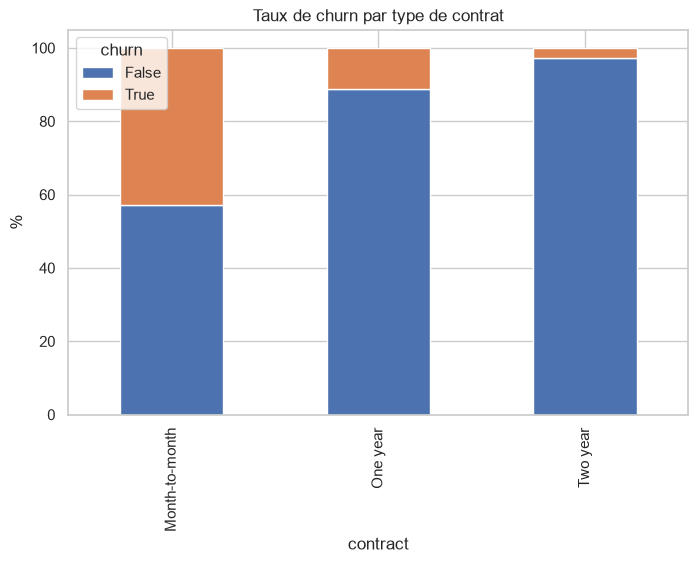

In [7]:
contract_col = [c for c in df.columns if "contract" in c.lower()][0]

ct = pd.crosstab(df[contract_col], df[churn_col], normalize="index") * 100
ct.plot(kind="bar", stacked=True, figsize=(8,5))
plt.title("Taux de churn par type de contrat")
plt.ylabel("%")
plt.show()

## 4. Churn par ancienneté (tenure)

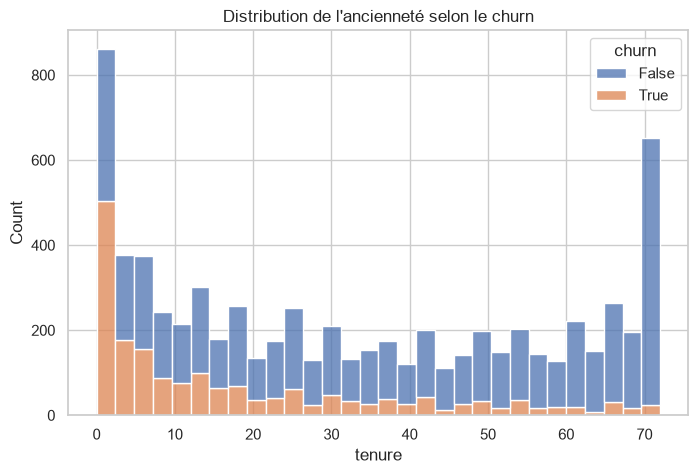

In [8]:
tenure_col = [c for c in df.columns if "tenure" in c.lower()][0]

plt.figure(figsize=(8,5))
sns.histplot(data=df, x=tenure_col, hue=churn_col, multiple="stack", bins=30)
plt.title("Distribution de l'ancienneté selon le churn")
plt.show()

## 5. Charges mensuelles vs churn

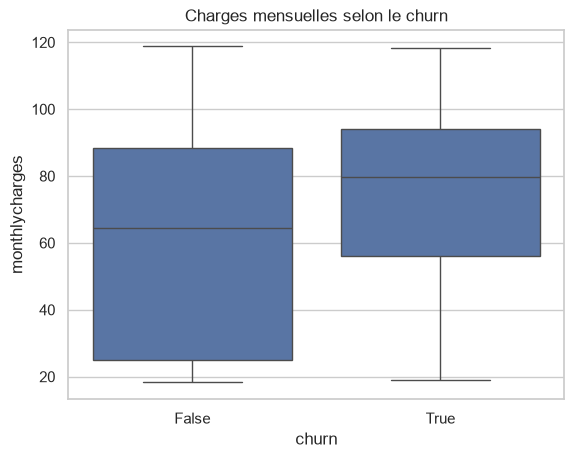

In [9]:
charges_col = [c for c in df.columns if "monthly" in c.lower() and "charge" in c.lower()][0]

sns.boxplot(data=df, x=churn_col, y=charges_col)
plt.title("Charges mensuelles selon le churn")
plt.show()

## 6. Matrice de corrélation (variables numériques)

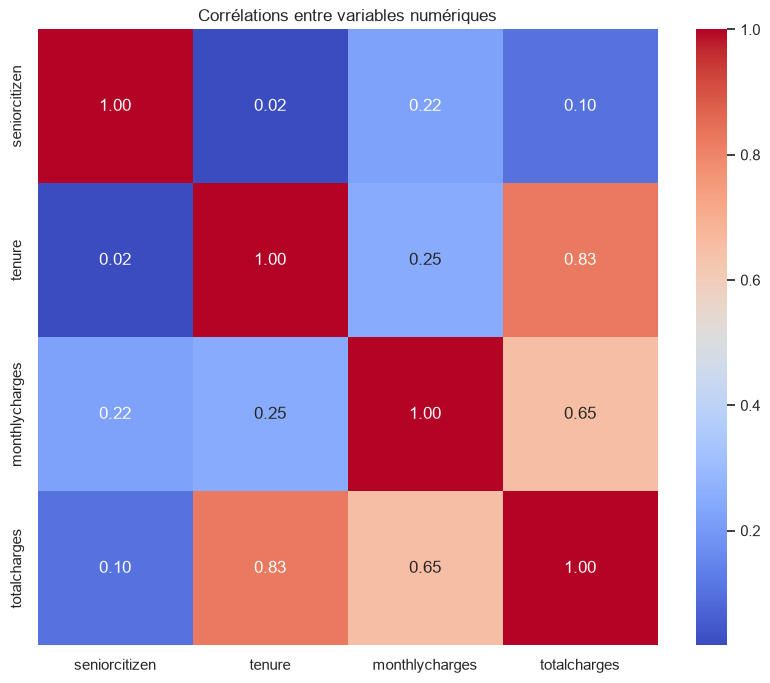

In [10]:
num_cols = df.select_dtypes(include=[np.number]).columns
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Corrélations entre variables numériques")
plt.show()